In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import statsmodels.api as sm

from ISLP.models import ModelSpec as MS
from ISLP.models import poly
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_curve, auc, mean_squared_error


# Model Validation

## Variation in Predictions
Train data, once, generated from:
$$
y = 2 - 1.5 X_1 + \epsilon
$$
Test main times and check MSE

In [ ]:
# reset seed
np.random.seed(100)

# number of samples
n = 50
# create x values
x = np.random.uniform(0, 15, size=n)
# set true coefficients
beta0_true = 2.0
beta1_true = -1.5
# set noise parameters
eps = 1.0
y = beta0_true + beta1_true * x + eps * np.random.normal(size=n)

train_df = pd.DataFrame({"x": x, "y": y})

# linear model

design = MS(['x'])
X_train = design.fit_transform(train_df)

# X_train = sm.add_constant(train_df["x"])
lm_fit = sm.OLS(train_df["y"], X_train).fit()

# testing error
n_tests = 1000
mse = np.empty(n_tests)

m = 50 # number of test samples per test set

for j in range(n_tests):
    x = np.random.uniform(0, 15, size=m)
    y = beta0_true + beta1_true * x + eps * np.random.normal(size=m)
    test_df = pd.DataFrame({"x": x, "y": y})
    X_test = design.transform(test_df)
    preds = lm_fit.predict(X_test)
    mse[j] = mean_squared_error(test_df["y"], preds)


Text(0, 0.5, 'Frequency')

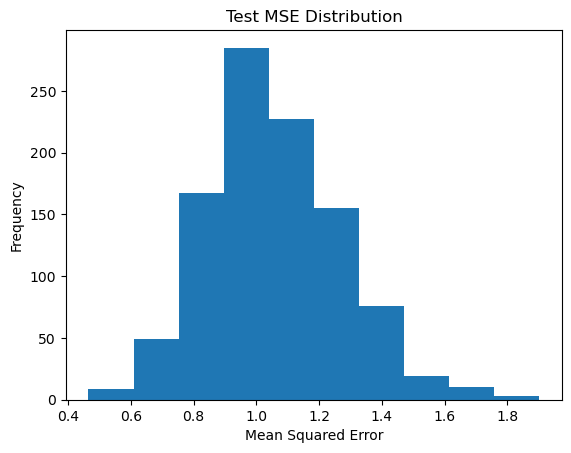

In [ ]:
fig, axes = plt.subplots()
axes.hist(mse, bins=10)
axes.set_title("Test MSE Distribution")
axes.set_xlabel("Mean Squared Error")
axes.set_ylabel("Frequency")

# Bias Variance Tradeoff
Try fitting data generated from
$$
Y = e^X(1 + \xi), \quad \xi \sim N(0,0.25)
$$
with polynomials of different degree.  Then evaluate how training and testing error varies as we try different degree polynomials.

In [ ]:
np.random.seed(100)

# test/train sample size
n = 10**2
# number of independent runs
m = 10**2

maxp = 10

# preallocate arrays
test_MSE_vals = np.zeros(maxp)
train_MSE_vals = np.zeros(maxp)

# generate training data
x_train = np.random.uniform(0, 5, n)
y_train = np.exp(x_train) * (1 + 0.5 * np.random.randn(n))
train_df = pd.DataFrame({"x": x_train, "y": y_train})

# loop over independent test sets
for j in range(m):

    # generate testing data
    x_test = np.random.uniform(0, 5, n)
    y_test = np.exp(x_test) * (1 + 0.5 * np.random.randn(n))
    test_df = pd.DataFrame({"x": x_test, "y": y_test})

    # try polynomial fits
    for p in range(1, maxp + 1):

        # create model specification using orthogonal polynomials
        design = MS([poly("x", degree=p)])
        
        X_train = design.fit_transform(train_df)
        X_test = design.transform(test_df)

        # fit model
        model = sm.OLS(train_df["y"], X_train).fit()

        # training MSE
        train_MSE_vals[p-1] += np.mean(model.resid**2) / m

        # testing MSE
        y_pred_test = model.predict(X_test)
        test_MSE_vals[p-1] += np.mean((test_df["y"] - y_pred_test)**2) / m




In [ ]:
fig, ax = plt.subplots()
ax.plot(range(1, maxp + 1), train_MSE_vals, label="Train MSE")
ax.plot(range(1, maxp + 1), test_MSE_vals, label="Test MSE")
ax.set_xlabel("Degree Polynomial")
ax.set_ylabel("MSE")
ax.set_title("MSE as a Function of Fit")
ax.legend()
